In [ ]:
Name: Sahil Suresh Ghogare

Roll no.: 23102A0061

Branch / Div: BE CMPN A

R_Assignment_2-Lab 4

**Installing Required Packages**

In [ ]:
install.packages("naniar")
install.packages("skimr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(naniar)
library(skimr)


Attaching package: ‘skimr’


The following object is masked from ‘package:naniar’:

    n_complete




**Extracting the dataset**

In [ ]:
unzip(
  "/content/adult.zip",
  exdir = "/content/adult_data"
)

list.files("/content/adult_data")

[1] "adult.data"      "adult.names"     "adult.test"      "Index"          
[5] "old.adult.names"

**Loading the Adult dataset**

In [ ]:
file_path <- "/content/adult_data/adult.data"

data <- read.csv(
  file_path,
  header = FALSE,
  na.strings = "?",
  strip.white = TRUE
)

colnames(data) <- c(
  "age",
  "workclass",
  "fnlwgt",
  "education",
  "education_num",
  "marital_status",
  "occupation",
  "relationship",
  "race",
  "sex",
  "capital_gain",
  "capital_loss",
  "hours_per_week",
  "native_country",
  "income"
)

head(data)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [ ]:
dim(data)
str(data)
summary(data)

[1] 32561    15

'data.frame':	32561 obs. of  15 variables:
 $ age           : int  39 50 38 53 28 37 49 52 31 42 ...
 $ workclass     : chr  "State-gov" "Self-emp-not-inc" "Private" "Private" ...
 $ fnlwgt        : int  77516 83311 215646 234721 338409 284582 160187 209642 45781 159449 ...
 $ education     : chr  "Bachelors" "Bachelors" "HS-grad" "11th" ...
 $ education_num : int  13 13 9 7 13 14 5 9 14 13 ...
 $ marital_status: chr  "Never-married" "Married-civ-spouse" "Divorced" "Married-civ-spouse" ...
 $ occupation    : chr  "Adm-clerical" "Exec-managerial" "Handlers-cleaners" "Handlers-cleaners" ...
 $ relationship  : chr  "Not-in-family" "Husband" "Not-in-family" "Husband" ...
 $ race          : chr  "White" "White" "White" "Black" ...
 $ sex           : chr  "Male" "Male" "Male" "Male" ...
 $ capital_gain  : int  2174 0 0 0 0 0 0 0 14084 5178 ...
 $ capital_loss  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hours_per_week: int  40 13 40 40 40 40 16 45 50 40 ...
 $ native_country: chr  "United-States" "Uni

      age            workclass         fnlwgt            education    
 Min.   :17.00   Length   :32561   Min.   :  12285   Length   :32561  
 1st Qu.:28.00   N.unique :    8   1st Qu.: 117827   N.unique :   16  
 Median :37.00   N.blank  :    0   Median : 178356   N.blank  :    0  
 Mean   :38.58   Min.nchar:    7   Mean   : 189778   Min.nchar:    3  
 3rd Qu.:48.00   Max.nchar:   16   3rd Qu.: 237051   Max.nchar:   12  
 Max.   :90.00   NAs      : 1836   Max.   :1484705                    
 education_num     marital_status      occupation       relationship  
 Min.   : 1.00   Length   :32561   Length   :32561   Length   :32561  
 1st Qu.: 9.00   N.unique :    7   N.unique :   14   N.unique :    6  
 Median :10.00   N.blank  :    0   N.blank  :    0   N.blank  :    0  
 Mean   :10.08   Min.nchar:    7   Min.nchar:    5   Min.nchar:    4  
 3rd Qu.:12.00   Max.nchar:   21   Max.nchar:   17   Max.nchar:   14  
 Max.   :16.00                     NAs      : 1843                    
      

**Introducing Missing and Invalid Values**

In [ ]:
# Introduce NA
data$age[1] <- NA

# Introduce blank string
data$workclass[2] <- ""

# Introduce NaN
data$capital_gain[3] <- NaN

# Introduce impossible age
data$age[4] <- 999

# Display modified rows
data[1:5, ]

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<dbl>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>
1,NA,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,NaN,0,40,United-States,<=50K
4,999,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


**Detecting Different Missing Values**

In [ ]:
sum(is.na(data))

sum(is.na(data$age))

[1] 4264

[1] 1

**Detecting NaN**

In [ ]:
sum(is.nan(data$capital_gain))

[1] 1

**Demonstrating NULL**

In [ ]:
x <- NULL

is.null(x)

[1] TRUE

In [ ]:
is.null(data$age)

[1] FALSE

**Detecting blank strings**

In [ ]:
sum(data$workclass == "", na.rm = TRUE)

[1] 1

**Detecting Impossible Age**

In [ ]:
sum(data$age == 999, na.rm = TRUE)

[1] 1

In [ ]:
data[data$age == 999, ]

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<dbl>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>
NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,999,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K


**Missing-Value Summary**

In [ ]:
miss_var_summary(data)

variable,n_miss,pct_miss
<chr>,<int>,<num>
occupation,1843,5.66
workclass,1836,5.64
native_country,583,1.79
age,1,0.003[4m0[24m[4m7[24m
capital_gain,1,0.003[4m0[24m[4m7[24m
fnlwgt,0,0
education,0,0
education_num,0,0
marital_status,0,0


**Missing Values Before Cleaning**

In [ ]:
missing_before <- sapply(data, function(x) {
  sum(is.na(x))
})

missing_before

age      workclass         fnlwgt      education  education_num 
             1           1836              0              0              0 
marital_status     occupation   relationship           race            sex 
             0           1843              0              0              0 
  capital_gain   capital_loss hours_per_week native_country         income 
             1              0              0            583              0

In [ ]:
missing_percentage_before <- sapply(data, function(x) {
  mean(is.na(x)) * 100
})

missing_percentage_before

age      workclass         fnlwgt      education  education_num 
   0.003071159    5.638647462    0.000000000    0.000000000    0.000000000 
marital_status     occupation   relationship           race            sex 
   0.000000000    5.660145573    0.000000000    0.000000000    0.000000000 
  capital_gain   capital_loss hours_per_week native_country         income 
   0.003071159    0.000000000    0.000000000    1.790485550    0.000000000

**Clean Impossible Age**

In [ ]:
data$age[data$age == 999] <- NA

In [ ]:
sum(data$age == 999, na.rm = TRUE)

[1] 0

**Replacing Blank Categorical Values**

In [ ]:
data$workclass[
  !is.na(data$workclass) & data$workclass == ""
] <- "Unknown"

In [ ]:
sum(data$workclass == "", na.rm = TRUE)

[1] 0

**Custom Median-Imputation Function**

In [ ]:
median_impute <- function(x) {

  if (!is.numeric(x)) {
    stop("Input must be numeric.")
  }

  median_value <- median(x, na.rm = TRUE)

  x[is.na(x)] <- median_value

  return(x)
}

In [ ]:
numeric_columns <- c(
  "age",
  "fnlwgt",
  "education_num",
  "capital_gain",
  "capital_loss",
  "hours_per_week"
)

for (col in numeric_columns) {
  data[[col]] <- median_impute(data[[col]])
}

**Handling NaN**

In [ ]:
nan_count <- sum(sapply(data, function(x) {
  if (is.numeric(x)) {
    sum(is.nan(x))
  } else {
    0
  }
}))

cat("NaN values:", nan_count, "\n")

NaN values: 0 


In [ ]:
data <- data[
  !apply(data, 1, function(row) {
    any(is.nan(as.numeric(row[1:1])))
  }),
]

In [ ]:
sum(is.nan(data$capital_gain))

[1] 0

**Complete Cases**

In [ ]:
complete_rows <- complete.cases(data)

cat("Complete observations:", sum(complete_rows), "\n")
cat("Incomplete observations:", sum(!complete_rows), "\n")

Complete observations: 30162 
Incomplete observations: 2399 


**Missing Values After Cleaning**

In [ ]:
missing_after <- sapply(data, function(x) {
  sum(is.na(x))
})

missing_after

age      workclass         fnlwgt      education  education_num 
             0           1836              0              0              0 
marital_status     occupation   relationship           race            sex 
             0           1843              0              0              0 
  capital_gain   capital_loss hours_per_week native_country         income 
             0              0              0            583              0

In [ ]:
missing_percentage_after <- sapply(data, function(x) {
  mean(is.na(x)) * 100
})

missing_percentage_after

age      workclass         fnlwgt      education  education_num 
      0.000000       5.638647       0.000000       0.000000       0.000000 
marital_status     occupation   relationship           race            sex 
      0.000000       5.660146       0.000000       0.000000       0.000000 
  capital_gain   capital_loss hours_per_week native_country         income 
      0.000000       0.000000       0.000000       1.790486       0.000000

**Before vs After Comparison**

In [ ]:
missing_comparison <- data.frame(
  Variable = names(missing_before),
  Before = as.numeric(missing_before),
  After = as.numeric(missing_after)
)

missing_comparison

Variable,Before,After
<chr>,<dbl>,<dbl>
age,1,0
workclass,1836,1836
fnlwgt,0,0
education,0,0
education_num,0,0
marital_status,0,0
occupation,1843,1843
relationship,0,0
race,0,0


**Visualizing Missingness**

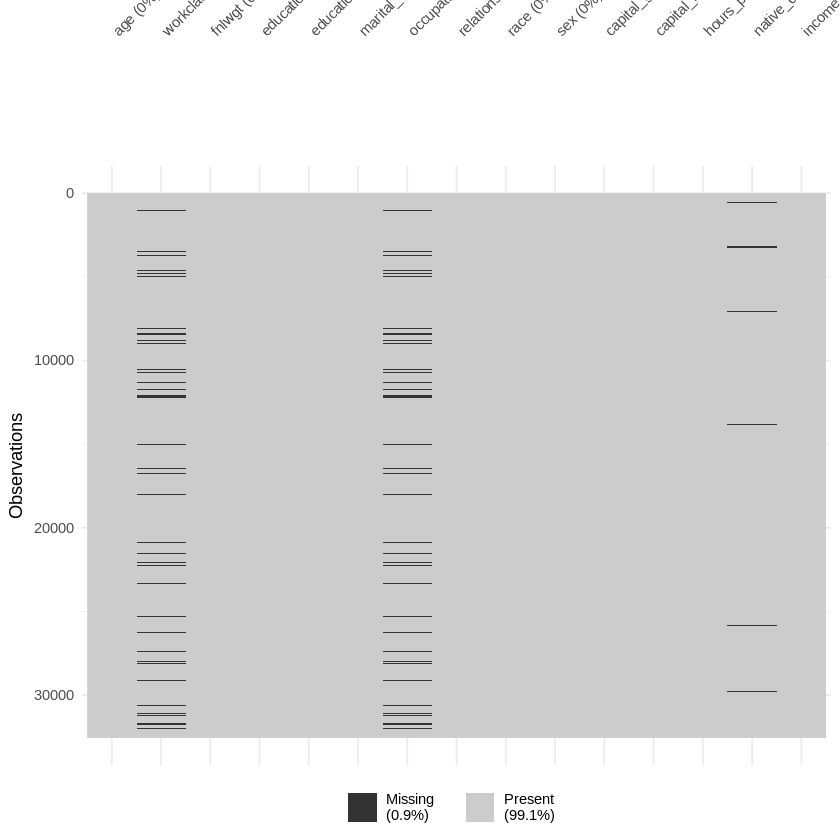

In [ ]:
vis_miss(data)

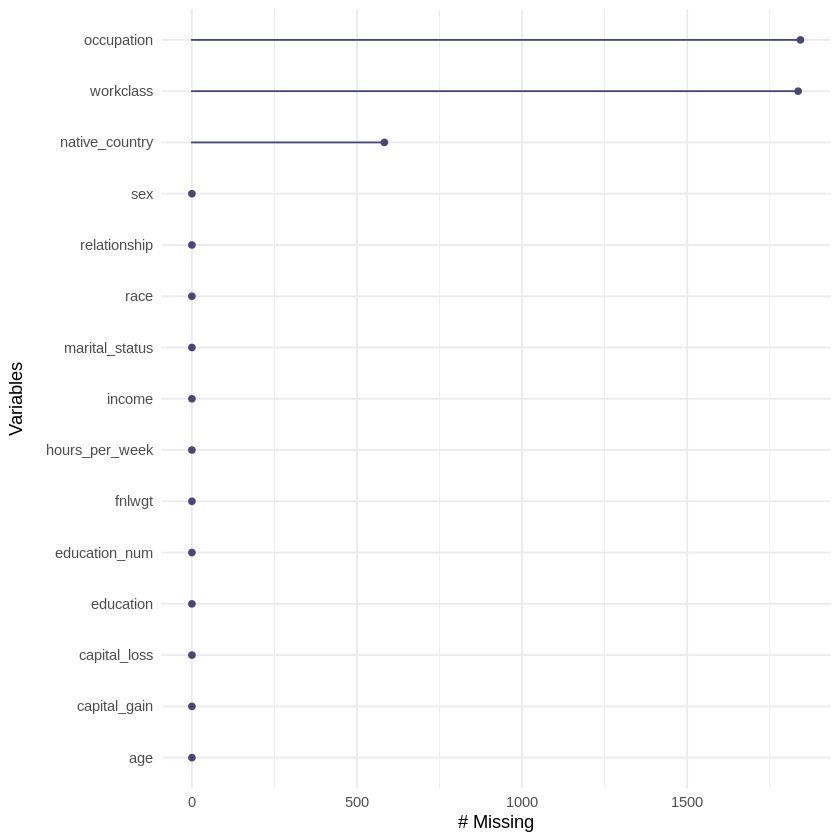

In [ ]:
gg_miss_var(data)

**Validating Using skimr**

In [ ]:
skim(data)

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,workclass,1836,0.9436135,7,16,0,9,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,education,0,1.0000000,3,12,0,16,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,marital_status,0,1.0000000,7,21,0,7,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,occupation,1843,0.9433985,5,17,0,14,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,relationship,0,1.0000000,4,14,0,6,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,race,0,1.0000000,5,18,0,5,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,sex,0,1.0000000,4,6,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,native_country,583,0.9820951,4,26,0,41,0,NA,NA,NA,NA,NA,NA,NA,NA
9,character,income,0,1.0000000,4,5,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA


**Verifying Age 999 Removed**

In [ ]:
sum(data$age == 999, na.rm = TRUE)

[1] 0

**Verifying Blank Values Removed**

In [ ]:
sum(data$workclass == "", na.rm = TRUE)

[1] 0

**Verifying Numeric Missing Values**

In [ ]:
sapply(
  data[numeric_columns],
  function(x) sum(is.na(x))
)

age         fnlwgt  education_num   capital_gain   capital_loss 
             0              0              0              0              0 
hours_per_week 
             0

**Saving Cleaned Dataset**

In [ ]:
write.csv(
  data,
  "/content/cleaned_adult_data.csv",
  row.names = FALSE
)

print("Cleaned Adult dataset saved successfully!")

[1] "Cleaned Adult dataset saved successfully!"
